In [1]:
%pip install mlflow
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\Ritesh gawade\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_p1_G = pd.read_csv('../data/raw/Plant_1_Generation_Data.csv')
df_p1_G.head(23)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0
5,15-05-2020 00:00,4135001,VHMLBKoKgIrUVDU,0.0,0.0,0.0,7206408.0
6,15-05-2020 00:00,4135001,WRmjgnKYAwPKWDb,0.0,0.0,0.0,7028673.0
7,15-05-2020 00:00,4135001,ZnxXDlPa8U1GXgE,0.0,0.0,0.0,6522172.0
8,15-05-2020 00:00,4135001,ZoEaEvLYb1n2sOq,0.0,0.0,0.0,7098099.0
9,15-05-2020 00:00,4135001,adLQvlD726eNBSB,0.0,0.0,0.0,6271355.0


In [3]:
df_p1_G.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [4]:
first_22 = set(df_p1_G['SOURCE_KEY'].head(22))
all_unique = set(df_p1_G['SOURCE_KEY'].unique())

print(first_22 == all_unique)  # True or False

False


In [5]:
df_p1_w = pd.read_csv('../data/raw/Plant_1_Weather_Sensor_Data.csv')
df_p1_w.head(44)

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.000000
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.000000
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.000000
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.000000
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.000000
5,2020-05-15 01:15:00,4135001,HmiyD2TTLFNqkNe,24.536092,21.968571,0.000000
6,2020-05-15 01:30:00,4135001,HmiyD2TTLFNqkNe,24.638674,22.352926,0.000000
7,2020-05-15 01:45:00,4135001,HmiyD2TTLFNqkNe,24.873022,23.160919,0.000000
8,2020-05-15 02:00:00,4135001,HmiyD2TTLFNqkNe,24.936930,23.026113,0.000000
9,2020-05-15 02:15:00,4135001,HmiyD2TTLFNqkNe,25.012248,23.343229,0.000000


In [6]:
df_p1_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB


In [7]:
df_p1_w[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].corr()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
AMBIENT_TEMPERATURE,1.000000,0.853778,0.722999
MODULE_TEMPERATURE,0.853778,1.000000,0.961566
IRRADIATION,0.722999,0.961566,1.000000


In [8]:
df_p1_G['DATE_TIME'] = pd.to_datetime(
    df_p1_G['DATE_TIME'],
    format='%d-%m-%Y %H:%M'
)

In [9]:
df_p1_w['DATE_TIME'] = pd.to_datetime(
    df_p1_w['DATE_TIME'],
)

In [10]:
print(df_p1_G['DATE_TIME'].dtype)
print(df_p1_w['DATE_TIME'].dtype)

datetime64[ns]
datetime64[ns]


In [11]:
df_p1_merged = pd.merge(df_p1_G, df_p1_w, on = ['DATE_TIME'], how='left')

In [12]:
print(df_p1_merged.duplicated().sum())

0


In [13]:
df_p1_merged.head(-5)

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
68768,2020-06-17 23:45:00,4135001,iCRJl6heRkivqQ3,0.0,0.0,5957.0,7426263.0,4135001.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68769,2020-06-17 23:45:00,4135001,ih0vzX44oOqAx2f,0.0,0.0,5758.0,6426129.0,4135001.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68770,2020-06-17 23:45:00,4135001,pkci93gMrogZuBj,0.0,0.0,5952.0,7415430.0,4135001.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0
68771,2020-06-17 23:45:00,4135001,rGa61gmuvPhdLxV,0.0,0.0,5950.0,7356897.0,4135001.0,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


In [14]:
df_p1_merged['SOURCE_KEY_x'].nunique()

22

In [15]:
df_p1_merged.duplicated().sum()

np.int64(0)

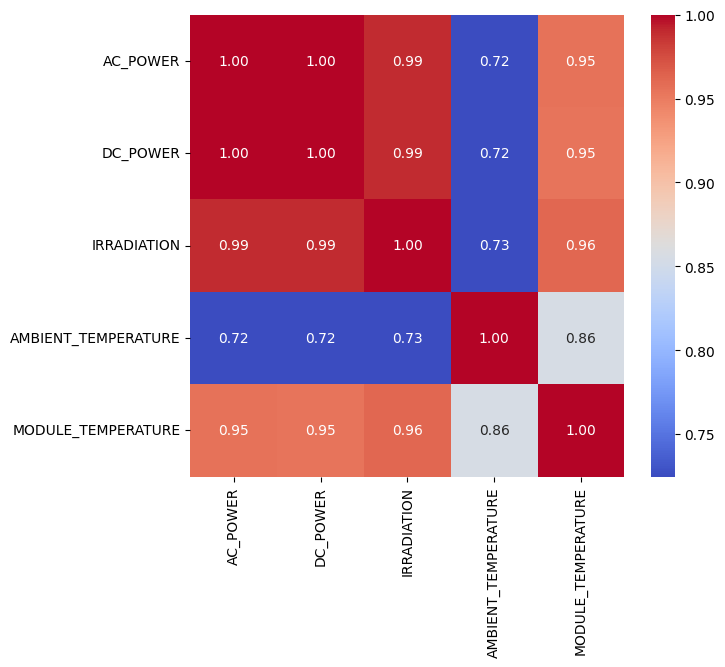

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "AC_POWER",
    "DC_POWER",
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE"
]

corr = df_p1_merged[features].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

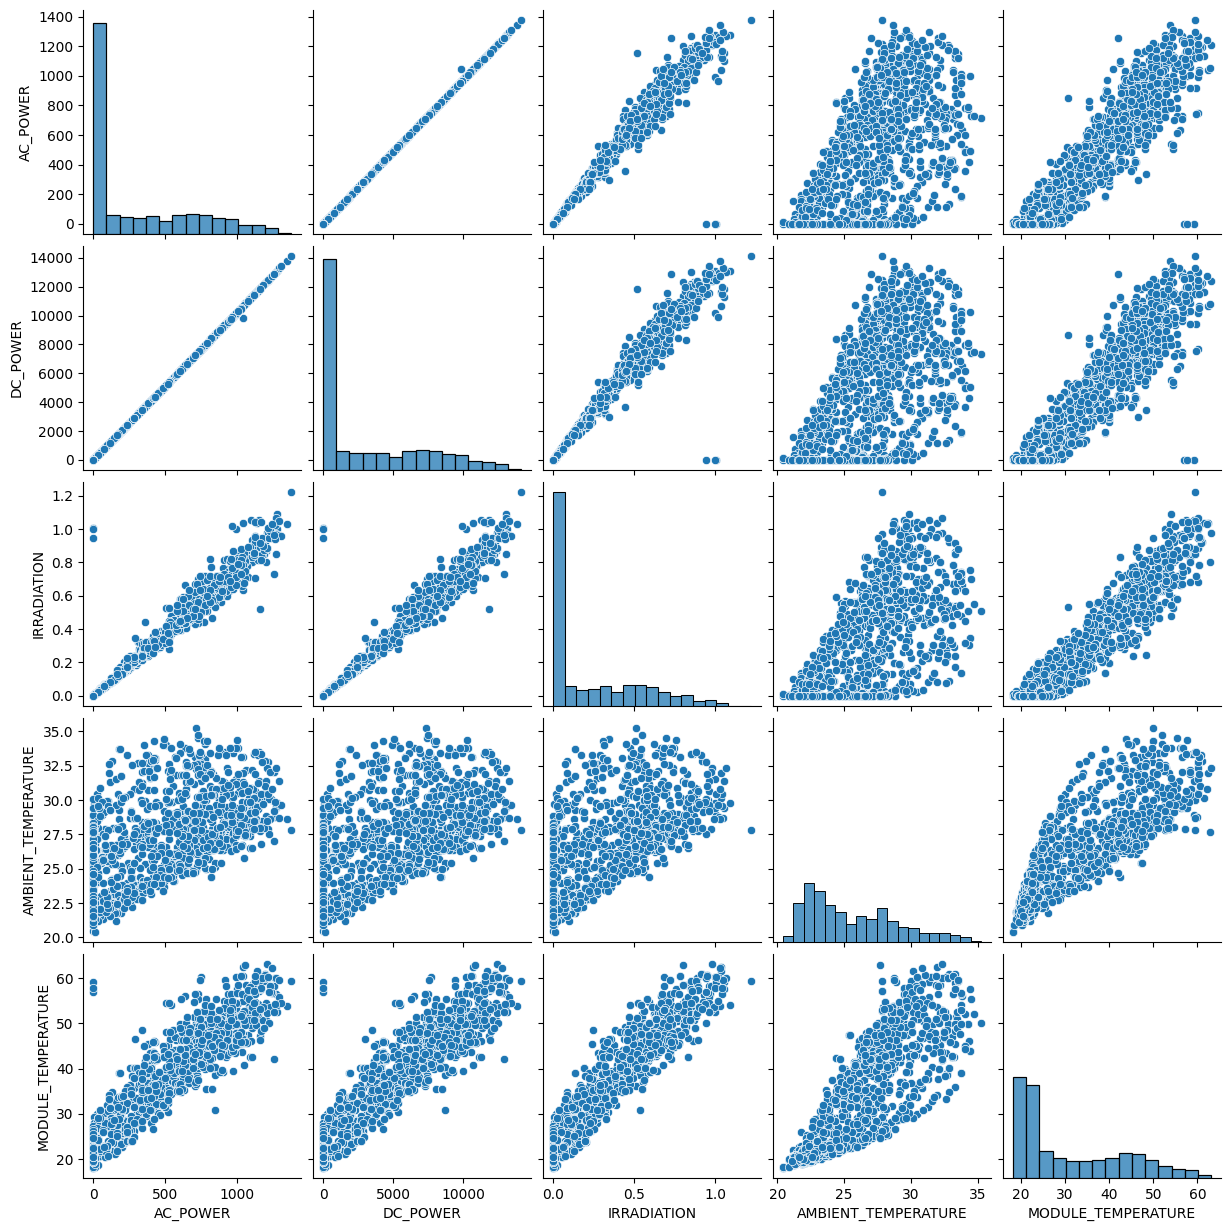

In [17]:
sample_df = df_p1_merged[features].sample(2000, random_state=42)

sns.pairplot(sample_df)
plt.show()

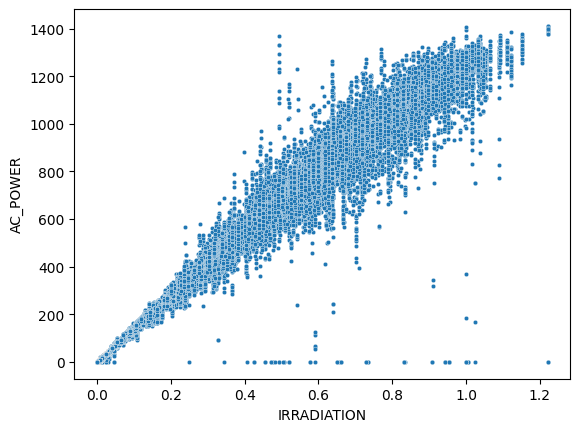

In [18]:
sns.scatterplot(
    data=df_p1_merged,
    x="IRRADIATION",
    y="AC_POWER",
    s=10
)

plt.show()

In [19]:
df = df_p1_merged[['AC_POWER','IRRADIATION', 'AMBIENT_TEMPERATURE','DC_POWER', 'DATE_TIME']]

In [20]:
df.head(23)

,AC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,DC_POWER,DATE_TIME
0,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
1,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
2,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
3,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
4,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
5,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
6,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
7,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
8,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00
9,0.0,0.0,25.184316,0.0,2020-05-15 00:00:00


In [21]:
df_plant = df.groupby('DATE_TIME').agg({
    'AC_POWER':'sum',
    'DC_POWER':'sum',
    'IRRADIATION':'mean',
    'AMBIENT_TEMPERATURE':'mean'
}).reset_index()

In [22]:
df_hourly = df_plant.resample('1H', on='DATE_TIME').mean().reset_index()

C:\Users\Ritesh gawade\AppData\Local\Temp\ipykernel_24896\909419030.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_plant.resample('1H', on='DATE_TIME').mean().reset_index()


In [23]:
df_hourly.head(-5)

,DATE_TIME,AC_POWER,DC_POWER,IRRADIATION,AMBIENT_TEMPERATURE
0,2020-05-15 00:00:00,0.000000,0.000000,0.000000,25.012697
1,2020-05-15 01:00:00,0.000000,0.000000,0.000000,24.667328
2,2020-05-15 02:00:00,0.000000,0.000000,0.000000,24.986837
3,2020-05-15 03:00:00,0.000000,0.000000,0.000000,24.954589
4,2020-05-15 04:00:00,0.000000,0.000000,0.000000,24.276670
...,...,...,...,...,...
806,2020-06-17 14:00:00,15344.710268,156749.575892,0.492675,28.689972
807,2020-06-17 15:00:00,4637.749107,47399.977678,0.140690,26.426544
808,2020-06-17 16:00:00,5294.725000,54000.433035,0.156274,24.049745
809,2020-06-17 17:00:00,2766.847946,28397.772322,0.086656,24.210150


In [24]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            816 non-null    datetime64[ns]
 1   AC_POWER             796 non-null    float64       
 2   DC_POWER             796 non-null    float64       
 3   IRRADIATION          796 non-null    float64       
 4   AMBIENT_TEMPERATURE  796 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 32.0 KB


In [25]:
df_hourly.duplicated().sum()

np.int64(0)

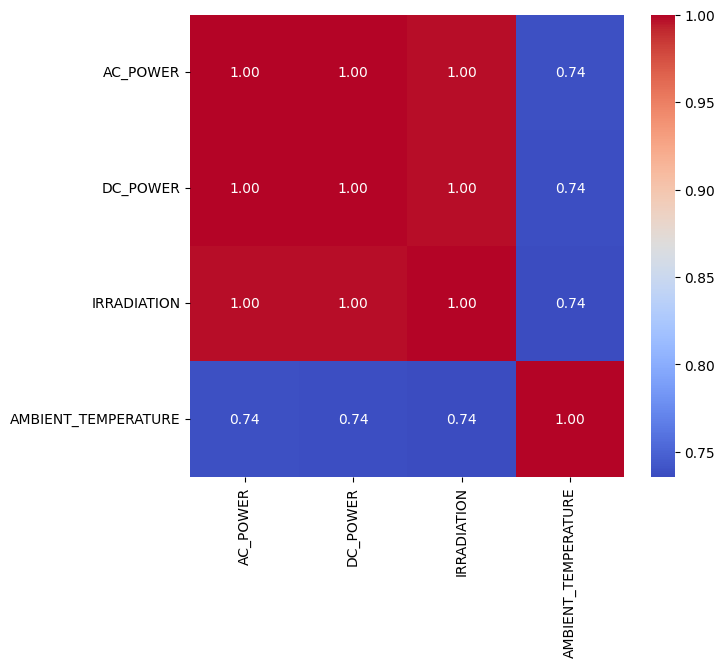

In [26]:
features = [
    "AC_POWER",
    "DC_POWER",
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
]

corr = df_hourly[features].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

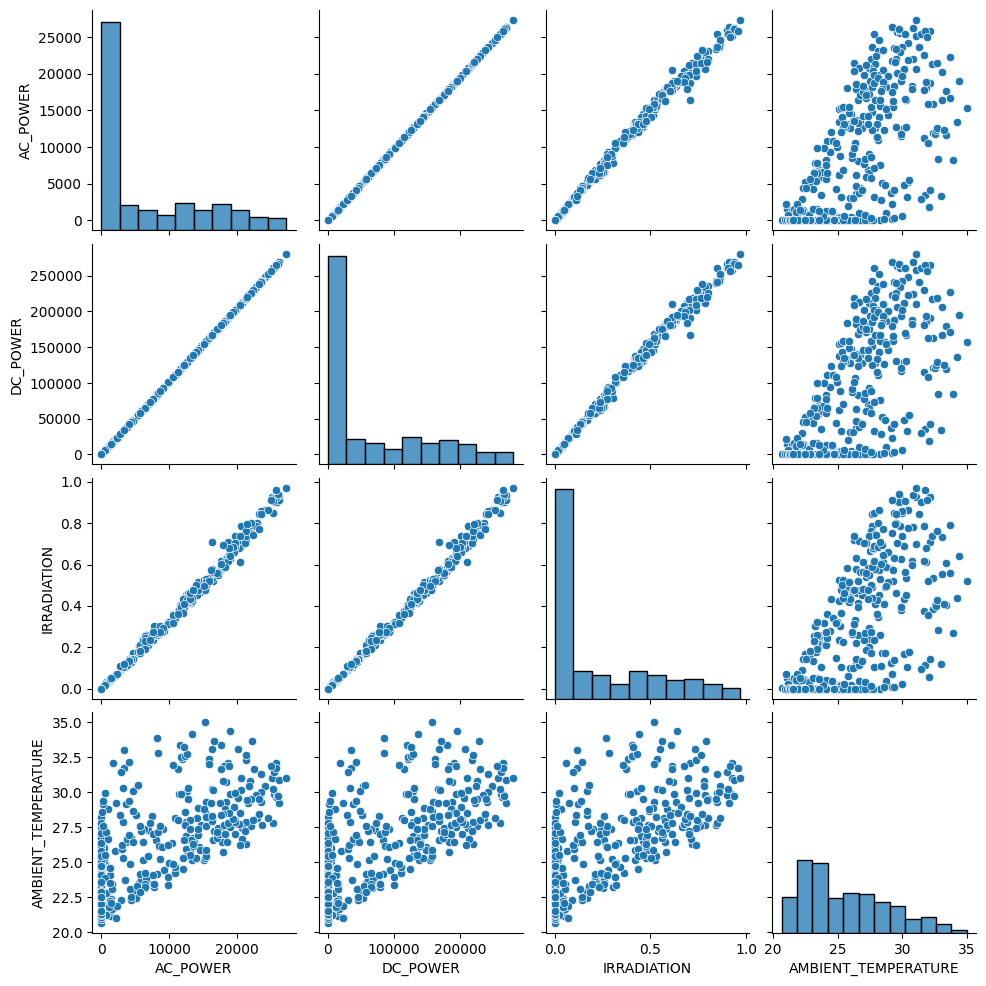

In [27]:
sample_df = df_hourly[features].sample(500, random_state=42)

sns.pairplot(sample_df)
plt.show()

In [28]:
df_hourly.drop(labels = ['DC_POWER'], axis=1, inplace=True, errors='ignore')

In [29]:
df_hourly.columns

Index(['DATE_TIME', 'AC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE'], dtype='object')

In [30]:
#Extract Time Features
df_hourly['HOUR'] = df_hourly['DATE_TIME'].dt.hour

Cyclical Encoding of Time (Hour Feature)

In this dataset, the HOUR feature represents the hour of the day (0–23). If we use the hour as a normal numerical value, the machine learning model treats time as a linear variable. However, time is actually cyclical.

For example:

Hour 23 and Hour 0 are only one hour apart in reality.

But numerically, the difference between them is 23, which makes them appear very far apart to the model.

This can confuse the model because the end of the day and the start of the day are actually connected.

In [31]:
df_hourly['HOUR_SIN'] = np.sin(2*np.pi*df_hourly['HOUR']/24)
df_hourly['HOUR_COS'] = np.cos(2*np.pi*df_hourly['HOUR']/24)

In [32]:
df_hourly = df_hourly.drop(columns=['HOUR'])

In [33]:
df_hourly = df_hourly[df_hourly['IRRADIATION'] > 0]

In [34]:
df_hourly.columns

Index(['DATE_TIME', 'AC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE',
       'HOUR_SIN', 'HOUR_COS'],
      dtype='object')

In [35]:
df = df_hourly.drop(columns=['DATE_TIME'])

In [36]:
df.columns

Index(['AC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'HOUR_SIN',
       'HOUR_COS'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 469 entries, 5 to 810
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AC_POWER             469 non-null    float64
 1   IRRADIATION          469 non-null    float64
 2   AMBIENT_TEMPERATURE  469 non-null    float64
 3   HOUR_SIN             469 non-null    float64
 4   HOUR_COS             469 non-null    float64
dtypes: float64(5)
memory usage: 22.0 KB


# Training

In [38]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [40]:
import mlflow

mlflow.set_tracking_uri("file:///../mlruns")
mlflow.set_experiment("SolarPowerForecasting")

c:\Users\Ritesh gawade\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/17 09:53:21 INFO mlflow.tracking.fluent: Experiment with name 'SolarPowerForecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/../mlruns/927558920112241566', creation_time=1773721401194, experiment_id='927558920112241566', last_update_time=1773721401194, lifecycle_stage='active', name='SolarPowerForecasting', tags={}, workspace='default'>

In [41]:
X = df.drop(columns=['AC_POWER'])
y = df['AC_POWER']

In [42]:
# Train 80%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Validation 10% | Test 10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [43]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

with mlflow.start_run(run_name="LinearRegression"):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    train_pred = pipeline.predict(X_train)
    val_pred = pipeline.predict(X_val)
    test_pred = pipeline.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    test_r2 = r2_score(y_test, test_pred)

    mse = mean_squared_error(y_test, test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, test_pred)

    # Log params
    mlflow.log_param("model", "LinearRegression")

    # Log metrics
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)

    # 🔥 IMPORTANT (fixed)
    mlflow.sklearn.log_model(pipeline, "model")

2026/03/17 09:53:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 09:53:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

with mlflow.start_run(run_name="RandomForest"):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor())
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    val_pred = pipeline.predict(X_val)
    test_pred = pipeline.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    test_r2 = r2_score(y_test, test_pred)

    mse = mean_squared_error(y_test, test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, test_pred)

    mlflow.log_param("model", "RandomForest")

    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)

    # 🔥 FIXED
    mlflow.sklearn.log_model(pipeline, "model")

2026/03/17 09:53:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 09:53:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

with mlflow.start_run(run_name="GradientBoosting"):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingRegressor())
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    val_pred = pipeline.predict(X_val)
    test_pred = pipeline.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    test_r2 = r2_score(y_test, test_pred)

    mse = mean_squared_error(y_test, test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, test_pred)

    mlflow.log_param("model", "GradientBoosting")

    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)

    # 🔥 FIXED
    mlflow.sklearn.log_model(pipeline, "model")

2026/03/17 09:53:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 09:53:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

with mlflow.start_run(run_name="XGBoost"):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(objective="reg:squarederror"))
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    val_pred = pipeline.predict(X_val)
    test_pred = pipeline.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    test_r2 = r2_score(y_test, test_pred)

    mse = mean_squared_error(y_test, test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, test_pred)

    mlflow.log_param("model", "XGBoost")

    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)

    # 🔥 FIXED
    mlflow.sklearn.log_model(pipeline, "model")

2026/03/17 09:53:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 09:53:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
